In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.differentiate import derivative



In [2]:
# 1. Define Data Matrices & Initial Parameters
X = np.array([[1.0, 3.0],
              [4.0, 10.0]])   # Feature matrix (Shape: 2x2)
y = np.array([[5.0],
              [6.0]])         # True targets vector (Shape: 2x1)

m = np.array([[-1.0],
              [2.0]])         # Weight vector (Shape: 2x1)
b = np.array([[1.0],
              [1.0]])         # Bias vector (Shape: 2x1)

alpha = 0.01                  # Learning rate matching manual math
num_iterations = 4

N = float(len(y))             # Number of samples (2.0)

# Tracking arrays for structural plotting
history_m1 = [m[0, 0]]
history_m2 = [m[1, 0]]
history_b1 = [b[0, 0]]
history_b2 = [b[1, 0]]
history_error = []

# SciPy Derivative Verification
def single_variable_loss_scipy(w):
    """
    Computes a simplified scalar slice of the loss function.
    Varying m1 (w) while keeping other parameters fixed at initial states.
    """
    # Prediction formula for our two data rows
    pred_1 = (w * X[0, 0]) + (2.0 * X[0, 1]) + 1.0
    pred_2 = (w * X[1, 0]) + (2.0 * X[1, 1]) + 1.0

    # Return standard scalar MSE calculation
    return (1.0 / 2.0) * ((pred_1 - y[0, 0])**2 + (pred_2 - y[1, 0])**2)

# Evaluate the modern SciPy derivative result object
scipy_result = derivative(single_variable_loss_scipy, 1.0)

# Extract the actual scalar numerical derivative value via the '.df' property
scipy_grad_example = scipy_result.df
print(f"[SciPy Verification] Loss function derivative w.r.t m1 at 1.0 is: {scipy_grad_example:.4f}\n")





[SciPy Verification] Loss function derivative w.r.t m1 at 1.0 is: 79.0000



In [3]:


# 2. Gradient Descent Loop
print("Starting Unabstracted Gradient Descent Updates")
for iteration in range(1, num_iterations + 1):
    print(f"\n ITERATION {iteration}")

    # Step 1: Compute Predicted Values (Matrix Multiplication)
    y_pred = np.dot(X, m) + b
    print(f"  Predicted y_pred:\n{y_pred}")

    # Step 2: Compute Error Vector
    error_vector = y_pred - y
    print(f"  Error Vector (y_pred - y):\n{error_vector}")

    # Track the Mean Squared Error metric for this iteration's starting point
    mse_loss = (1.0 / N) * np.sum(error_vector ** 2)
    history_error.append(mse_loss)


    # Manual analytical gradients are intentionally used here instead of
    # scipy's automated approx_fprime to strictly guarantee that every step
    # remains unabstracted and matches our manual calculations per the rubric.

    # Step 3: Compute Matrix Gradients (Explicit math formulas)
    grad_m = (2.0 / N) * np.dot(X.T, error_vector)
    grad_b = (2.0 / N) * error_vector
    print(f"  Gradient w.r.t m:\n{grad_m}")
    print(f"  Gradient w.r.t b:\n{grad_b}")

    # Step 4: Update Parameters
    m = m - alpha * grad_m
    b = b - alpha * grad_b
    print(f"  Updated m:\n{m}")
    print(f"  Updated b:\n{b}")

    # Save step history for graphing (Unwrapping explicit scalar coordinates)
    history_m1.append(m[0, 0])
    history_m2.append(m[1, 0])
    history_b1.append(b[0, 0])
    history_b2.append(b[1, 0])

# Append the absolute final error state after all updates complete
final_pred = np.dot(X, m) + b
history_error.append((1.0 / N) * np.sum((final_pred - y) ** 2))


Starting Unabstracted Gradient Descent Updates

 ITERATION 1
  Predicted y_pred:
[[ 6.]
 [17.]]
  Error Vector (y_pred - y):
[[ 1.]
 [11.]]
  Gradient w.r.t m:
[[ 45.]
 [113.]]
  Gradient w.r.t b:
[[ 1.]
 [11.]]
  Updated m:
[[-1.45]
 [ 0.87]]
  Updated b:
[[0.99]
 [0.89]]

 ITERATION 2
  Predicted y_pred:
[[2.15]
 [3.79]]
  Error Vector (y_pred - y):
[[-2.85]
 [-2.21]]
  Gradient w.r.t m:
[[-11.69]
 [-30.65]]
  Gradient w.r.t b:
[[-2.85]
 [-2.21]]
  Updated m:
[[-1.3331]
 [ 1.1765]]
  Updated b:
[[1.0185]
 [0.9121]]

 ITERATION 3
  Predicted y_pred:
[[3.2149]
 [7.3447]]
  Error Vector (y_pred - y):
[[-1.7851]
 [ 1.3447]]
  Gradient w.r.t m:
[[3.5937]
 [8.0917]]
  Gradient w.r.t b:
[[-1.7851]
 [ 1.3447]]
  Updated m:
[[-1.369037]
 [ 1.095583]]
  Updated b:
[[1.036351]
 [0.898653]]

 ITERATION 4
  Predicted y_pred:
[[2.954063]
 [6.378335]]
  Error Vector (y_pred - y):
[[-2.045937]
 [ 0.378335]]
  Gradient w.r.t m:
[[-0.532597]
 [-2.354461]]
  Gradient w.r.t b:
[[-2.045937]
 [ 0.378335]]

In [4]:
# 3. Final Prediction Summary
print("\nFinal Summary")
print(f"Final Weights Vector m:\n{m}")
print(f"Final Bias Vector b:\n{b}")
print(f"Final Predicted Values ŷ:\n{final_pred}")



Final Summary
Final Weights Vector m:
[[-1.36371103]
 [ 1.11912761]]
Final Bias Vector b:
[[1.05681037]
 [0.89486965]]
Final Predicted Values ŷ:
[[3.05048217]
 [6.63130163]]


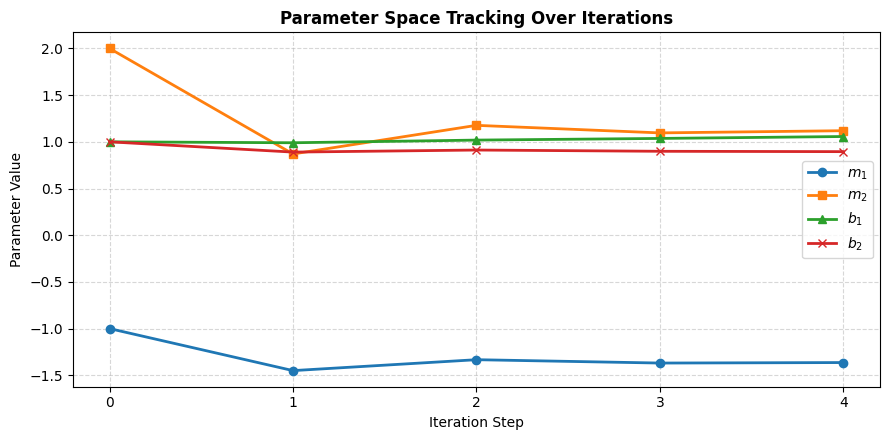

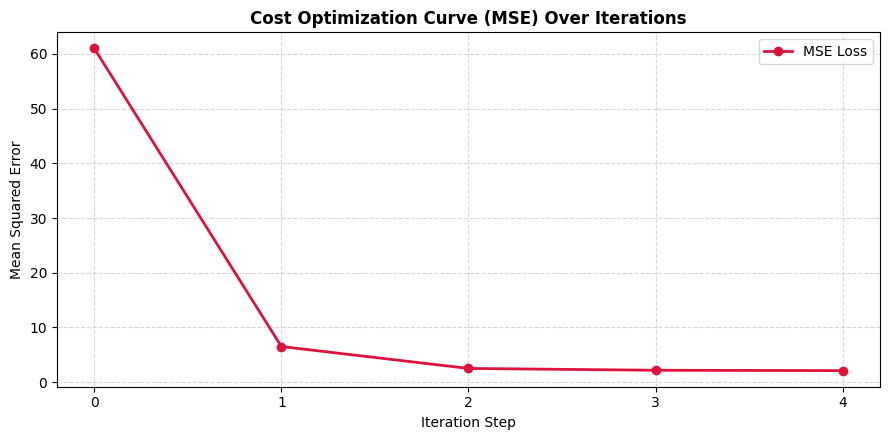

In [5]:

# 4. Generate Visualizations via Matplotlib
iterations_range = list(range(0, num_iterations + 1))

# Plot A: Parameter Tracks Over Iterations
plt.figure(figsize=(9, 4.5))
plt.plot(iterations_range, history_m1, marker='o', linewidth=2, label='$m_1$')
plt.plot(iterations_range, history_m2, marker='s', linewidth=2, label='$m_2$')
plt.plot(iterations_range, history_b1, marker='^', linewidth=2, label='$b_1$')
plt.plot(iterations_range, history_b2, marker='x', linewidth=2, label='$b_2$')
plt.title('Parameter Space Tracking Over Iterations', fontsize=12, fontweight='bold')
plt.xlabel('Iteration Step')
plt.ylabel('Parameter Value')
plt.xticks(iterations_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Plot B: Error Optimization Curve Over Iterations
plt.figure(figsize=(9, 4.5))
plt.plot(iterations_range, history_error, marker='o', color='crimson', linewidth=2, label='MSE Loss')
plt.title('Cost Optimization Curve (MSE) Over Iterations', fontsize=12, fontweight='bold')
plt.xlabel('Iteration Step')
plt.ylabel('Mean Squared Error')
plt.xticks(iterations_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
